# Layer 1: Pose Extraction

Extract 33-joint coordinates from the master video using MediaPipe Pose,
then visually verify extraction quality via skeleton overlay video.

**Input**: `sample_videos/chon_ji_master.mp4`  
**Output**:
- `sample_videos/chon_ji_master_poses.json` — per-frame joint coordinates
- `sample_videos/chon_ji_master_overlay.mp4` — skeleton overlay video

In [11]:
import sys
import pathlib

# Add project root to sys.path (two levels up from notebooks/)
project_root = pathlib.Path().resolve().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"project_root: {project_root}")

project_root: E:\Projects\Saas\Taekwon


In [12]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
POOMSAE    = "do_san"   # poomsae identifier — used to name output files
VIDEO_TYPE = "master"    # "master"  or  student name, e.g. "student1"
# ──────────────────────────────────────────────────────────────────────────────

In [13]:
from itf_analysis.pose_extraction.extractor import (
    extract_poses_from_video,
    interpolate_missing_landmarks,
    compute_visibility_stats,
    save_poses_to_json,
    visualize_pose_overlay,
)

sample_dir  = project_root / "itf_analysis" / "sample_videos"
poomsae_dir = sample_dir / POOMSAE
poomsae_dir.mkdir(parents=True, exist_ok=True)

VIDEO_PATH   = str(poomsae_dir / f"{VIDEO_TYPE}.mp4")
JSON_OUT     = str(poomsae_dir / f"{VIDEO_TYPE}_poses.json")
OVERLAY_OUT  = str(poomsae_dir / f"{VIDEO_TYPE}_overlay.mp4")

VISIBILITY_THRESHOLD = 0.5
print("video path:", VIDEO_PATH)

video path: E:\Projects\Saas\Taekwon\itf_analysis\sample_videos\do_san\master.mp4


In [14]:
# Run pose extraction with visibility filtering
frames = extract_poses_from_video(VIDEO_PATH, visibility_threshold=VISIBILITY_THRESHOLD)

total    = len(frames)
detected = sum(1 for f in frames if f.landmarks)
print(f"\ntotal frames : {total}")
print(f"pose detected: {detected} ({detected/total*100:.1f}%)")
print(f"no detection : {total - detected}")

  processing: 0/1283 frames
  processing: 100/1283 frames
  processing: 200/1283 frames
  processing: 300/1283 frames
  processing: 400/1283 frames
  processing: 500/1283 frames
  processing: 600/1283 frames
  processing: 700/1283 frames
  processing: 800/1283 frames
  processing: 900/1283 frames
  processing: 1000/1283 frames
  processing: 1100/1283 frames
  processing: 1200/1283 frames

done: 1283 frames total, pose detected in 1283 frames (100.0%)

total frames : 1283
pose detected: 1283 (100.0%)
no detection : 0


## Visibility Distribution

Histogram of raw MediaPipe visibility scores (before interpolation).
Landmarks below the threshold (red line) are treated as missing.

  processing: 0/1283 frames
  processing: 100/1283 frames
  processing: 200/1283 frames
  processing: 300/1283 frames
  processing: 400/1283 frames
  processing: 500/1283 frames
  processing: 600/1283 frames
  processing: 700/1283 frames
  processing: 800/1283 frames
  processing: 900/1283 frames
  processing: 1000/1283 frames
  processing: 1100/1283 frames
  processing: 1200/1283 frames

done: 1283 frames total, pose detected in 1283 frames (100.0%)


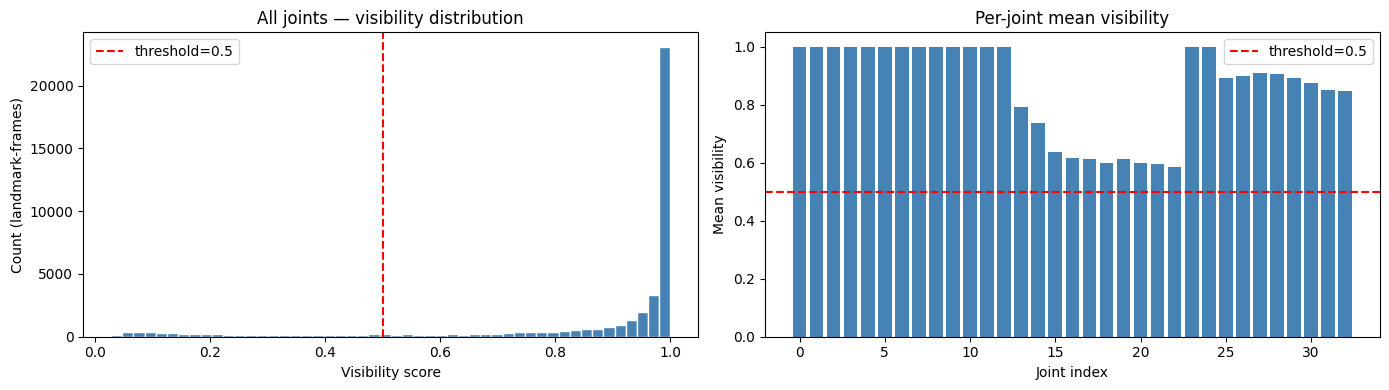

Landmark-frames below threshold: 4883 / 42339 (11.5%)


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Re-extract with threshold=0.0 to see the full raw distribution
frames_raw = extract_poses_from_video(VIDEO_PATH, visibility_threshold=0.0)

all_vis = [
    lm.visibility
    for f in frames_raw
    for lm in f.landmarks.values()
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overall histogram
axes[0].hist(all_vis, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(VISIBILITY_THRESHOLD, color='red', linestyle='--',
                label=f'threshold={VISIBILITY_THRESHOLD}')
axes[0].set_xlabel('Visibility score')
axes[0].set_ylabel('Count (landmark-frames)')
axes[0].set_title('All joints — visibility distribution')
axes[0].legend()

# Per-joint mean visibility
stats = compute_visibility_stats(frames_raw)
joint_means = [np.mean(v) if v else 0.0 for v in stats.values()]
colors = ['red' if m < VISIBILITY_THRESHOLD else 'steelblue' for m in joint_means]
axes[1].bar(range(33), joint_means, color=colors)
axes[1].axhline(VISIBILITY_THRESHOLD, color='red', linestyle='--',
                label=f'threshold={VISIBILITY_THRESHOLD}')
axes[1].set_xlabel('Joint index')
axes[1].set_ylabel('Mean visibility')
axes[1].set_title('Per-joint mean visibility')
axes[1].legend()

plt.tight_layout()
plt.show()

below = sum(1 for v in all_vis if v < VISIBILITY_THRESHOLD)
print(f"Landmark-frames below threshold: {below} / {len(all_vis)} "
      f"({below/len(all_vis)*100:.1f}%)")

In [16]:
# Interpolate frames where joints dropped below threshold
frames = interpolate_missing_landmarks(frames)

Interpolation complete: 4883 landmark-frames filled.


In [17]:
# Inspect a sample frame
first_detected = next(f for f in frames if f.landmarks)
print(f"=== frame_index={first_detected.frame_index}, t={first_detected.timestamp_ms:.0f}ms ===")
print(f"landmarks: {len(first_detected.landmarks)}")

key_joints = {
    11: 'left shoulder',  12: 'right shoulder',
    23: 'left hip',       24: 'right hip',
    25: 'left knee',      26: 'right knee',
    27: 'left ankle',     28: 'right ankle',
}
for idx, name in key_joints.items():
    lm = first_detected.landmarks.get(idx)
    if lm:
        interp = ' [interp]' if lm.visibility == 0.0 else ''
        print(f"  {idx:2d} {name}: x={lm.x:.3f} y={lm.y:.3f} z={lm.z:.3f} vis={lm.visibility:.2f}{interp}")

=== frame_index=0, t=0ms ===
landmarks: 33
  11 left shoulder: x=0.603 y=0.320 z=-0.034 vis=1.00
  12 right shoulder: x=0.553 y=0.325 z=-0.049 vis=1.00
  23 left hip: x=0.593 y=0.450 z=0.006 vis=1.00
  24 right hip: x=0.565 y=0.449 z=-0.006 vis=1.00
  25 left knee: x=0.595 y=0.535 z=0.041 vis=0.97
  26 right knee: x=0.562 y=0.533 z=0.042 vis=0.98
  27 left ankle: x=0.596 y=0.608 z=0.165 vis=0.96
  28 right ankle: x=0.556 y=0.606 z=0.178 vis=0.96


In [18]:
# Save to JSON
save_poses_to_json(frames, JSON_OUT)

JSON saved: E:\Projects\Saas\Taekwon\itf_analysis\sample_videos\do_san\master_poses.json (1283 frames)


In [19]:
# Generate overlay video
visualize_pose_overlay(VIDEO_PATH, frames, OVERLAY_OUT)

Overlay video saved: E:\Projects\Saas\Taekwon\itf_analysis\sample_videos\do_san\master_overlay.mp4


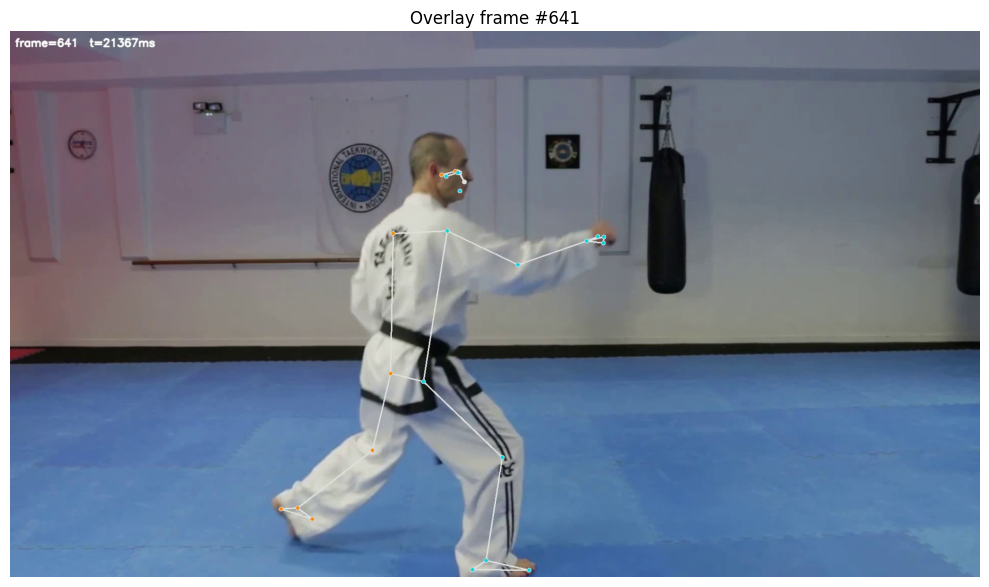

In [20]:
# Display a mid-point frame from the overlay video inline
import cv2

cap = cv2.VideoCapture(OVERLAY_OUT)
mid = len(frames) // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, mid)
ret, bgr = cap.read()
cap.release()

if ret:
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(rgb)
    plt.title(f"Overlay frame #{mid}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Could not read overlay video.")

## Validation Checklist

- [ ] Pose detection rate > 80%
- [ ] `frames[0].landmarks` contains all 33 joints
- [ ] Landmarks below visibility threshold are absent before interpolation
- [ ] Interpolated landmarks are marked with `visibility=0.0`
- [ ] No joint consistently below threshold (red bars in per-joint chart)
- [ ] JSON file saved successfully
- [ ] Skeleton aligns accurately with the master's body in the overlay video
- [ ] Skeleton is maintained through fast transition frames

All items passing → proceed to Layer 2 (normalization).